In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("..")

# Metaprompt Tuning Evaluation

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from patient_simulator.misc.plotting import save_to_figures

plt.style.use(Path("../patient_simulator/misc/style.mplstyle"))

In [3]:
df = pd.read_csv("../results/metaprompt_tuning/step_reward.csv")
step_results = pd.read_csv("../results/metaprompt_tuning/step_results.csv")

## Data And Feature Engineering
Load reward logs and create derived metrics used in all downstream analyses.

In [4]:
import json
import numpy as np

df = df.copy()
step_results = step_results.copy()


def _safe_load_dict(value):
    if isinstance(value, dict):
        return value
    if not isinstance(value, str) or value.strip() == "":
        return {}
    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, dict) else {}
    except json.JSONDecodeError:
        return {}


df["fidelity_distribution_dict"] = df["fidelity_distribution"].apply(_safe_load_dict)
df["supported_count"] = df["fidelity_distribution_dict"].apply(
    lambda d: int(d.get("Supported", 0))
)
df["hallucination_count"] = df["fidelity_distribution_dict"].apply(
    lambda d: int(d.get("Hallucination", 0))
)
df["fact_total"] = df["supported_count"] + df["hallucination_count"]
df["supported_rate"] = np.where(
    df["fact_total"] > 0, df["supported_count"] / df["fact_total"], 0.0
)
df["hallucination_rate"] = np.where(
    df["fact_total"] > 0, df["hallucination_count"] / df["fact_total"], 0.0
)

axes = ["h", "e", "x", "a", "c", "o"]
for axis in axes:
    df[f"{axis}_abs_dev"] = (
        pd.to_numeric(df[f"{axis}_recon"], errors="coerce")
        - pd.to_numeric(df[f"{axis}_trait"], errors="coerce")
    ).abs()
df["mean_axis_abs_dev"] = df[[f"{axis}_abs_dev" for axis in axes]].mean(axis=1)

df["meta_prompt"] = df["meta_prompt"].astype(str).str.strip()
step_results["prompt"] = step_results["prompt"].astype(str).str.strip()

prompt_sequence = pd.concat(
    [df["meta_prompt"], step_results["prompt"]],
    ignore_index=True,
).dropna()
all_prompts = pd.Index(pd.unique(prompt_sequence))
prompt_id_map = {name: i + 1 for i, name in enumerate(all_prompts)}

df["prompt_id"] = df["meta_prompt"].map(prompt_id_map).astype(int)
df["meta_prompt_short"] = (
    df["meta_prompt"].str.replace("\n", " ", regex=False).str.slice(0, 55)
)

prompt_lookup = pd.DataFrame(
    {
        "meta_prompt": list(all_prompts),
    }
)
prompt_lookup["prompt_id"] = prompt_lookup["meta_prompt"].map(prompt_id_map).astype(int)
prompt_lookup["meta_prompt_short"] = (
    prompt_lookup["meta_prompt"].str.replace("\n", " ", regex=False).str.slice(0, 55)
)
prompt_lookup = prompt_lookup.sort_values("prompt_id").reset_index(drop=True)

step_results["step"] = pd.to_numeric(step_results["step"], errors="raise").astype(int)
step_results["score"] = pd.to_numeric(step_results["score"], errors="raise")
step_results = step_results.drop(
    columns=["prompt_id", "meta_prompt", "meta_prompt_short"],
    errors="ignore",
)
step_results = step_results.merge(
    prompt_lookup[["prompt_id", "meta_prompt", "meta_prompt_short"]],
    left_on="prompt",
    right_on="meta_prompt",
    how="left",
)

df["trait_profile"] = (
    "H"
    + df["h_trait"].astype(str)
    + "_E"
    + df["e_trait"].astype(str)
    + "_X"
    + df["x_trait"].astype(str)
    + "_A"
    + df["a_trait"].astype(str)
    + "_C"
    + df["c_trait"].astype(str)
    + "_O"
    + df["o_trait"].astype(str)
    + "_L"
    + df["cefr_level"].astype(str)
)

prompt_summary = (
    df.groupby(["prompt_id", "meta_prompt", "meta_prompt_short"], as_index=False)
    .agg(
        n_eval=("reward", "size"),
        reward_mean=("reward", "mean"),
        reward_std=("reward", "std"),
        hallucination_rate_mean=("hallucination_rate", "mean"),
        mean_axis_abs_dev=("mean_axis_abs_dev", "mean"),
    )
    .sort_values("reward_mean", ascending=False)
    .reset_index(drop=True)
)

In [5]:
last_step = step_results["step"].max()
final_pop_scores = (
    step_results[step_results["step"] == last_step]
    .groupby("prompt_id")["score"]
    .last()
    .sort_values(ascending=False)
)
rank_label_map = {int(pid): f"#{i + 1}" for i, pid in enumerate(final_pop_scores.index)}

## Evolving over steps

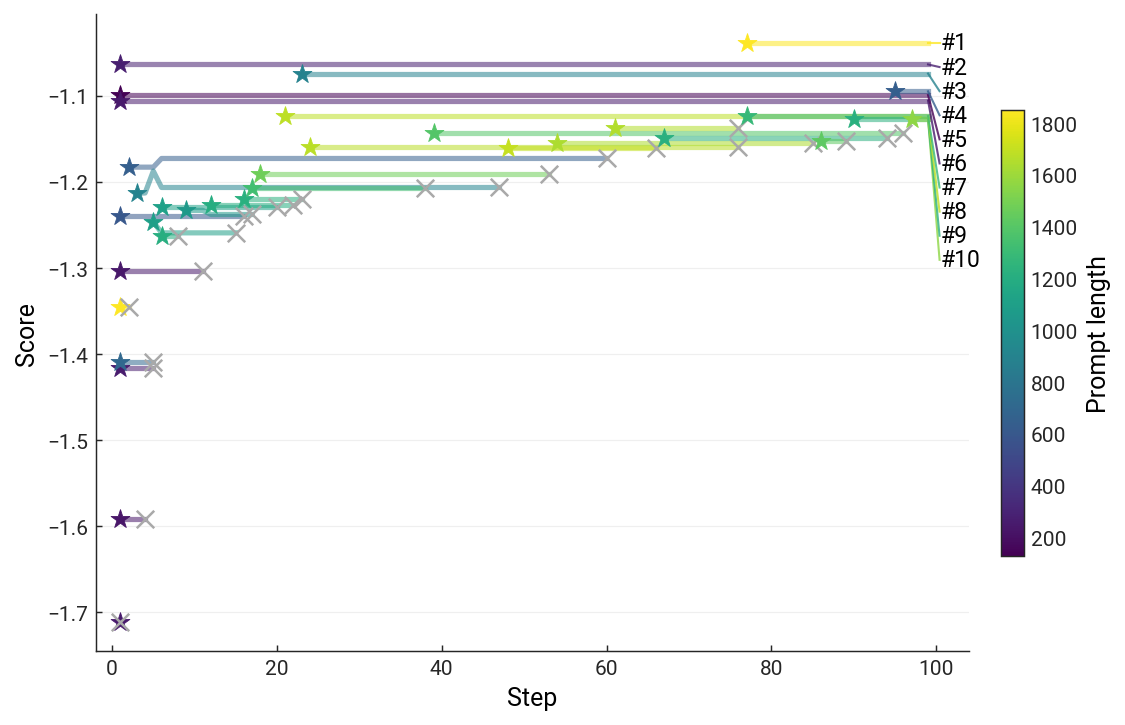

In [18]:
plot_df = step_results.copy()
plot_df["prompt_length"] = plot_df["prompt"].astype(str).str.len()
plot_df = plot_df.sort_values(["prompt_id", "step"]).reset_index(drop=True)

length_by_prompt = plot_df.groupby("prompt_id")["prompt_length"].first()
norm = plt.Normalize(length_by_prompt.min(), length_by_prompt.max())
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(8, 5))
max_step = plot_df["step"].max()

for prompt_id, prompt_df in plot_df.groupby("prompt_id", sort=False):
    prompt_df = prompt_df.sort_values("step").drop_duplicates("step", keep="last")
    color = cmap(norm(length_by_prompt.loc[prompt_id]))

    segment_id = prompt_df["step"].diff().fillna(1).ne(1).cumsum()
    for _, segment in prompt_df.groupby(segment_id):
        if len(segment) > 1:
            ax.plot(
                segment["step"],
                segment["score"],
                color=color,
                linewidth=2.5,
                alpha=0.55,
            )

    first_row = prompt_df.iloc[0]
    ax.scatter(
        first_row["step"], first_row["score"], marker="*", s=90, color=color, zorder=3
    )

    prompt_steps = set(prompt_df["step"].tolist())
    for _, row in prompt_df.iterrows():
        if row["step"] < max_step and (row["step"] + 1) not in prompt_steps:
            ax.scatter(
                row["step"], row["score"], marker="x", s=70, color="darkgrey", zorder=3
            )

last_step_points = (
    plot_df.loc[plot_df["step"] == max_step, ["prompt_id", "score"]]
    .sort_values("score")
    .drop_duplicates("prompt_id", keep="last")
    .reset_index(drop=True)
)

if len(last_step_points) > 0:
    y_values = last_step_points["score"].to_numpy()
    y_min = float(y_values.min())
    y_max = float(y_values.max())
    y_span = y_max - y_min
    min_gap = max(0.2 * y_span, 0.028)

    adjusted = []
    for y in y_values:
        if not adjusted:
            adjusted.append(float(y))
        else:
            adjusted.append(max(float(y), adjusted[-1] + min_gap))

    if adjusted[-1] > y_max:
        shift = adjusted[-1] - y_max
        adjusted = [val - shift for val in adjusted]

    x_label = max_step + 1.5
    for row, y_text in zip(last_step_points.itertuples(index=False), adjusted):
        color = cmap(norm(length_by_prompt.loc[row.prompt_id]))
        label = rank_label_map.get(int(row.prompt_id), str(int(row.prompt_id)))
        ax.plot(
            [max_step, x_label - 0.1],
            [row.score, y_text],
            color=color,
            linewidth=1.0,
            alpha=0.8,
        )
        ax.text(
            x_label,
            y_text,
            label,
            color="black",
            fontsize=11,
            va="center",
            ha="left",
            zorder=4,
        )

ax.set_xlabel("Step")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.2, linewidth=0.6)
ax.set_xlim(plot_df["step"].min() - 3.0, max_step + 5.0)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.03, label="Prompt length", shrink=0.7)

fig.tight_layout()

save_to_figures(fig, "metaprompt_tuning_step_scores")

plt.show()

In [7]:
# print ids of prompts that were alive in the last step
last_step = plot_df["step"].max()
alive_prompts = plot_df[plot_df["step"] == last_step]["prompt_id"].unique()
print("Prompts alive at the end of the last step:")
for prompt_id in alive_prompts:
    prompt_info = prompt_lookup[prompt_lookup["prompt_id"] == prompt_id].iloc[0]
    print(f"Prompt ID: {prompt_id}, Length: {len(prompt_info['meta_prompt'])}")

Prompts alive at the end of the last step:
Prompt ID: 1, Length: 129
Prompt ID: 2, Length: 273
Prompt ID: 5, Length: 245
Prompt ID: 92, Length: 1680
Prompt ID: 102, Length: 884
Prompt ID: 316, Length: 1285
Prompt ID: 318, Length: 1846
Prompt ID: 369, Length: 1220
Prompt ID: 388, Length: 635
Prompt ID: 397, Length: 1559


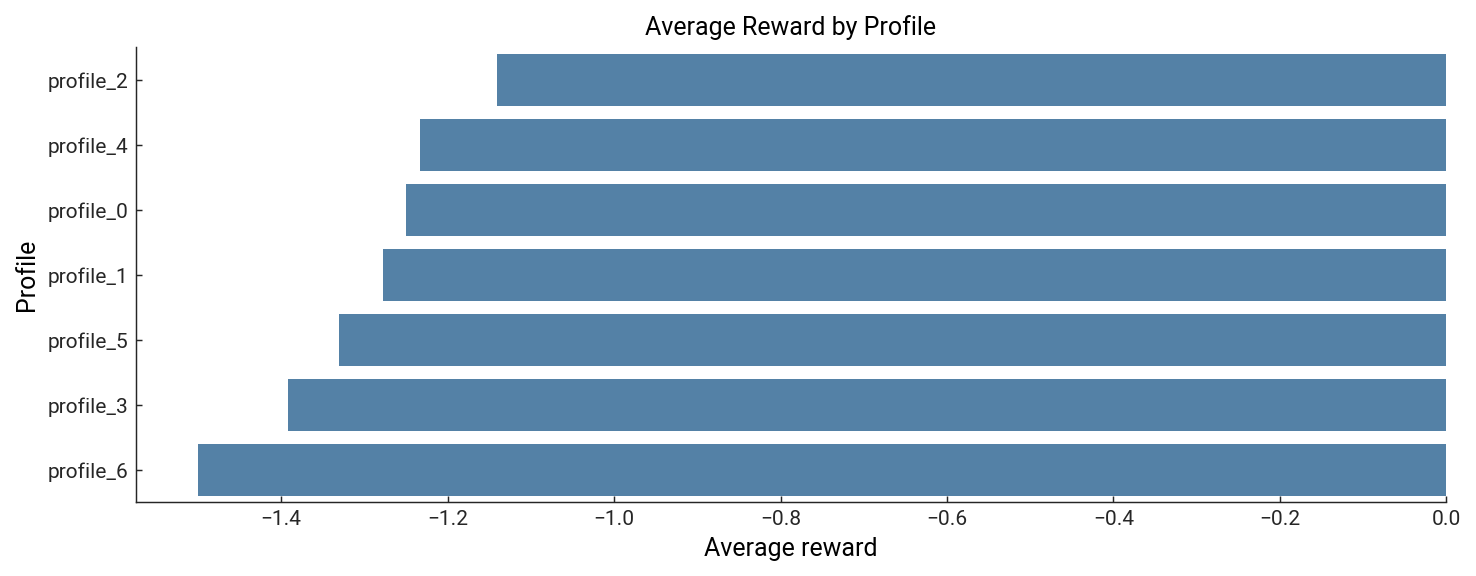

In [8]:
profile_reward = (
    df.assign(profile=df["row_id"].str.extract(r"^(profile_\d+)", expand=False))
    .dropna(subset=["profile"])
    .groupby("profile", as_index=False)
    .agg(
        n_eval=("reward", "size"),
        reward_mean=("reward", "mean"),
        reward_std=("reward", "std"),
    )
    .sort_values("reward_mean", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, max(4, 0.35 * len(profile_reward))))
sns.barplot(
    data=profile_reward,
    x="reward_mean",
    y="profile",
    color="steelblue",
    orient="h",
)
plt.xlabel("Average reward")
plt.ylabel("Profile")
plt.title("Average Reward by Profile")
plt.tight_layout()
plt.show()

<Axes: xlabel='information_penalty', ylabel='Count'>

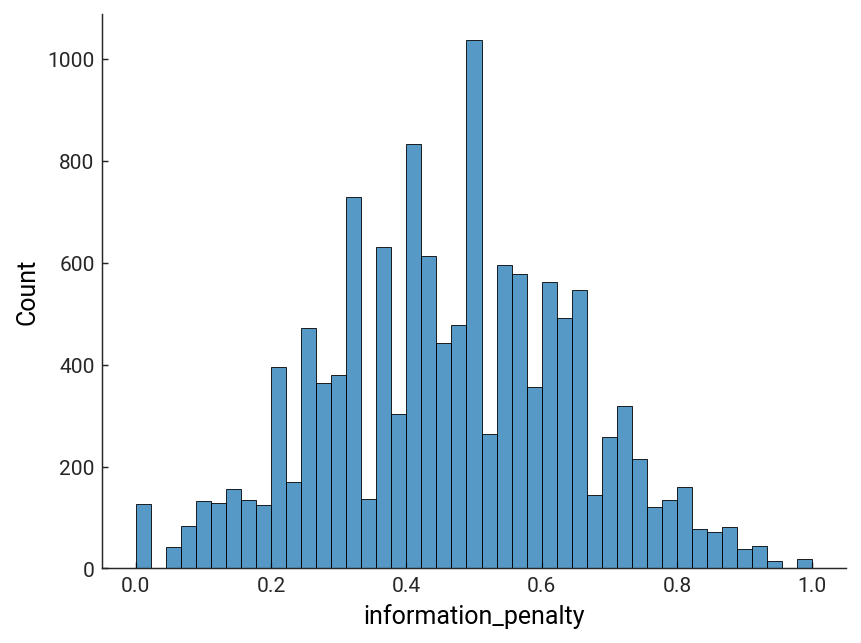

In [9]:
sns.histplot(df["information_penalty"])

<Axes: xlabel='personality_penalty', ylabel='Count'>

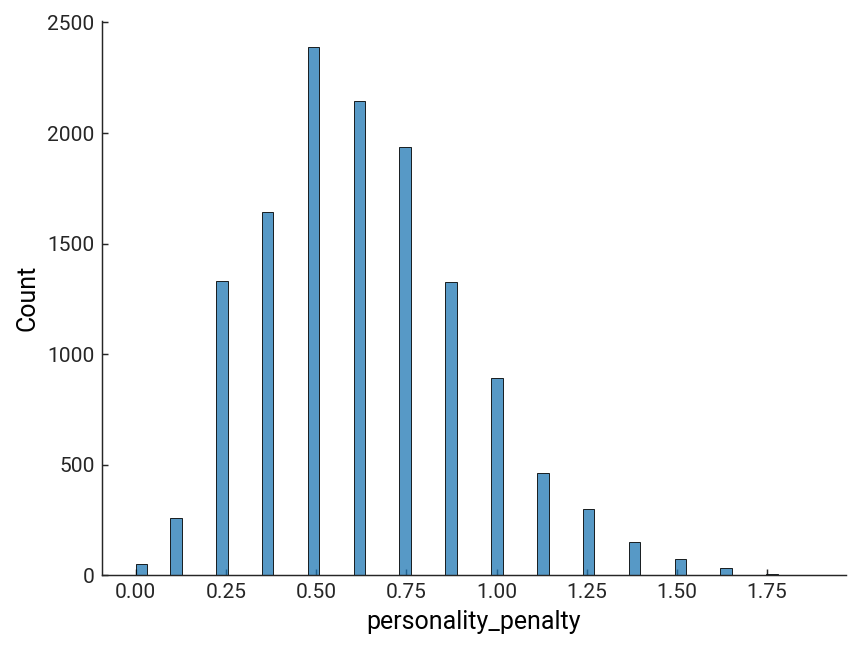

In [10]:
sns.histplot(df["personality_penalty"])

<Axes: xlabel='personal_info_penalty', ylabel='Count'>

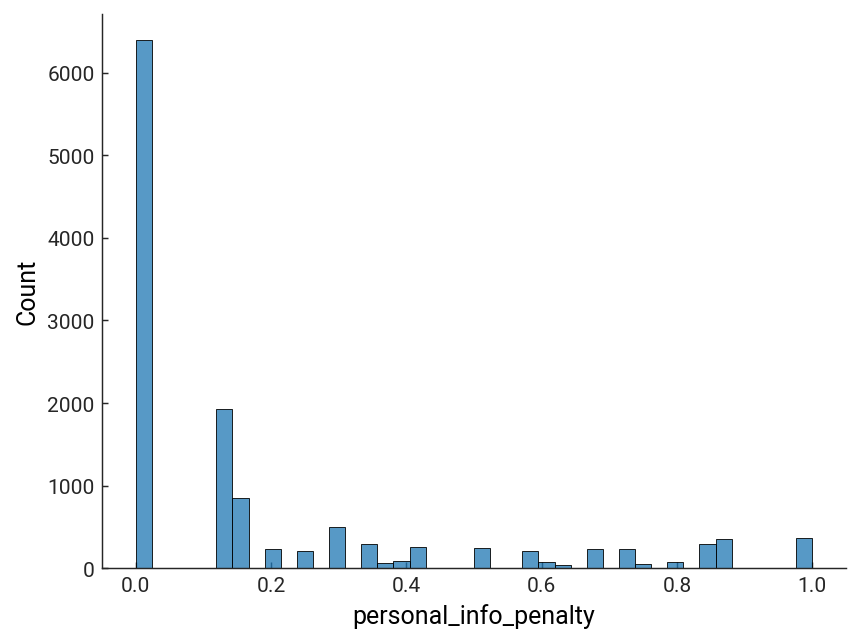

In [11]:
sns.histplot(df["personal_info_penalty"])

## Final population performance

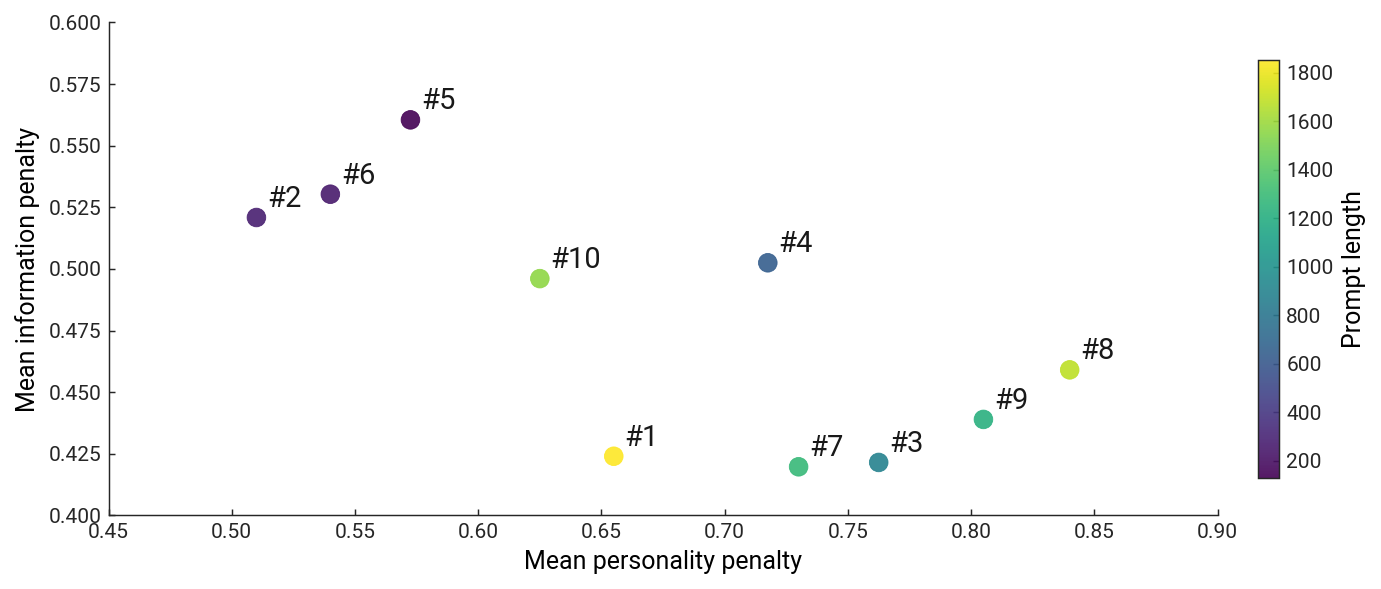

In [19]:
eval_reward = pd.read_csv("../results/metaprompt_tuning/eval_reward.csv")


eval_prompt_metrics = (
    eval_reward.groupby("meta_prompt", as_index=False)
    .agg(
        reward_mean=("reward", "mean"),
        information_penalty_mean=("information_penalty", "mean"),
        personality_penalty_mean=("personality_penalty", "mean"),
        n_eval=("reward", "size"),
    )
    .merge(
        prompt_lookup[["meta_prompt", "prompt_id"]],
        on="meta_prompt",
        how="left",
        validate="one_to_one",
    )
    .sort_values("reward_mean", ascending=False)
    .reset_index(drop=True)
)

if eval_prompt_metrics["prompt_id"].isna().any():
    raise ValueError("Some eval prompts could not be mapped to prompt_id.")

eval_prompt_metrics["prompt_length"] = eval_prompt_metrics["meta_prompt"].str.len()

fig, ax = plt.subplots(figsize=(10, 5))

scatter = ax.scatter(
    eval_prompt_metrics["personality_penalty_mean"],
    eval_prompt_metrics["information_penalty_mean"],
    c=eval_prompt_metrics["prompt_length"],
    cmap=cmap,
    norm=norm,
    s=80,
    alpha=0.9,
)

for row in eval_prompt_metrics.itertuples(index=False):
    label = rank_label_map.get(int(row.prompt_id), str(int(row.prompt_id)))
    ax.annotate(
        label,
        (row.personality_penalty_mean, row.information_penalty_mean),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=14,
        alpha=0.9,
    )

ax.set_xlabel("Mean personality penalty")
ax.set_ylabel("Mean information penalty")
ax.set_aspect("equal")

ax.set_xlim(0.45, 0.9)
ax.set_ylim(0.4, 0.6)

cbar = fig.colorbar(scatter, ax=ax, pad=0.03, shrink=0.6)
cbar.set_label("Prompt length")

fig.tight_layout()

save_to_figures(fig, "metaprompt_tuning_penalty_tradeoff")

plt.show()

In [13]:
eval_reward

,time,optimization_step,meta_prompt,row_id,cefr_level,h_trait,e_trait,x_trait,a_trait,c_trait,...,fidelity_output_token_count,personal_info_distribution,personal_info_fields,personal_info_presence,personal_info_input_token_count,personal_info_output_token_count,score_async_input_token_count,score_async_output_token_count,probe_logs,latent_role_prediction
0,2026-04-04 06:24:49,NaN,"Design a meticulously crafted, behaviorally au...",profile_8_sample_10,C,3,2,1,1,2,...,0,"{""Contained"": 6, ""Missing"": 1}","[{""field"": ""age"", ""value"": ""47""}, {""field"": ""m...","{""age"": {""value"": ""47"", ""contained"": true}, ""m...",284,0,4167,437,"[{""probe_idx"": 1, ""question"": ""Can you tell me...",<patient_profile>\n <demographics>\n ...
1,2026-04-04 06:25:28,NaN,"Design a meticulously crafted, behaviorally au...",profile_7_sample_22,B,2,2,3,2,2,...,0,"{""Contained"": 8, ""Missing"": 0}","[{""field"": ""age"", ""value"": ""26""}, {""field"": ""g...","{""age"": {""value"": ""26"", ""contained"": true}, ""g...",305,0,8027,915,"[{""probe_idx"": 1, ""question"": ""Can you tell me...",<patient_profile>\n <demographics>\n ...
2,2026-04-04 06:25:58,NaN,"Design a meticulously crafted, behaviorally au...",profile_8_sample_25,C,3,2,3,2,1,...,0,"{""Contained"": 7, ""Missing"": 1}","[{""field"": ""age"", ""value"": ""47""}, {""field"": ""m...","{""age"": {""value"": ""47"", ""contained"": true}, ""m...",322,0,6986,1043,"[{""probe_idx"": 1, ""question"": ""Can you tell me...",<patient_profile>\n <demographics>\n ...
3,2026-04-04 06:26:40,NaN,"Design a meticulously crafted, behaviorally au...",profile_9_sample_10,B,3,2,1,3,3,...,0,"{""Contained"": 8, ""Missing"": 0}","[{""field"": ""age"", ""value"": ""59""}, {""field"": ""g...","{""age"": {""value"": ""59"", ""contained"": true}, ""g...",277,0,6029,648,"[{""probe_idx"": 1, ""question"": ""Can you tell me...",<patient_profile>\n <demographics>\n ...
4,2026-04-04 06:27:09,NaN,"Design a meticulously crafted, behaviorally au...",profile_7_sample_0,B,2,3,3,3,3,...,0,"{""Contained"": 7, ""Missing"": 1}","[{""field"": ""age"", ""value"": ""26""}, {""field"": ""g...","{""age"": {""value"": ""26"", ""contained"": true}, ""g...",315,0,8376,1057,"[{""probe_idx"": 1, ""question"": ""Can you tell me...","<patient_identity>\n <name>alexandra ""a..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2026-04-04 09:28:43,NaN,Create a **behavioral framework** for a simula...,profile_7_sample_13,C,1,2,3,1,3,...,0,"{""Contained"": 6, ""Missing"": 2}","[{""field"": ""age"", ""value"": ""26""}, {""field"": ""g...","{""age"": {""value"": ""26"", ""contained"": true}, ""g...",340,0,6939,629,"[{""probe_idx"": 1, ""question"": ""Can you tell me...",<!-- behavioral framework for simulated patien...
496,2026-04-04 09:29:08,NaN,Create a **behavioral framework** for a simula...,profile_7_sample_24,A,3,3,2,1,3,...,0,"{""Contained"": 7, ""Missing"": 0}","[{""field"": ""age"", ""value"": ""26""}, {""field"": ""g...","{""age"": {""value"": ""26"", ""contained"": true}, ""g...",330,0,6470,525,"[{""probe_idx"": 1, ""question"": ""Can you tell me...",<!-- behavioral framework for simulated patien...
497,2026-04-04 09:29:29,NaN,Create a **behavioral framework** for a simula...,profile_7_sample_3,A,2,2,1,2,1,...,0,"{""Contained"": 6, ""Missing"": 1}","[{""field"": ""age"", ""value"": ""26""}, {""field"": ""g...","{""age"": {""value"": ""26"", ""contained"": true}, ""g...",346,0,6517,644,"[{""probe_idx"": 1, ""question"": ""Can you tell me...","**simulated patient profile: ""aria voss""**\n*d..."
498,2026-04-04 09:29:54,NaN,Create a **behavioral framework** for a simula...,profile_7_sample_17,A,1,2,3,3,3,...,0,"{""Contained"": 5, ""Missing"": 3}","[{""field"": ""age"", ""value"": ""26""}, {""field"": ""g...","{""age"": {""value"": ""26"", ""contained"": true}, ""g...",326,0,6559,669,"[{""probe_idx"": 1, ""question"": ""Can you tell me...",<!-- behavioral framework for simulated patien...


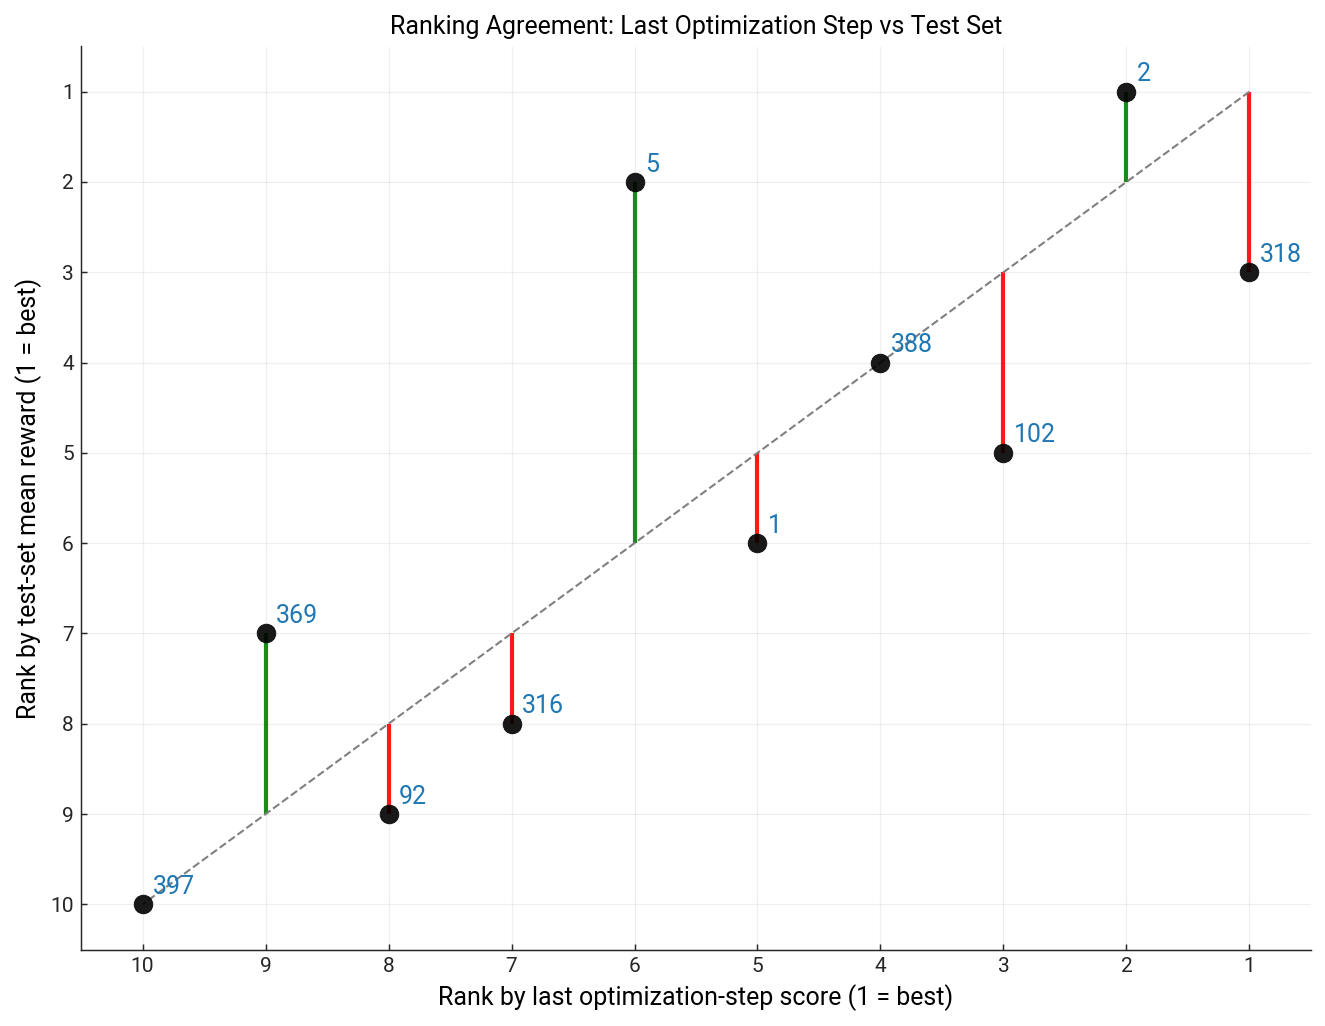

,prompt_id,last_step_score,eval_mean_reward,last_step_rank,test_reward_rank,rank_delta
0,2,-1.063402,-1.110632,2,1,-1
1,5,-1.105413,-1.137743,6,2,-4
2,318,-1.038447,-1.143397,1,3,2
3,388,-1.094650,-1.234515,4,4,0
4,102,-1.073968,-1.248703,3,5,2
5,1,-1.098971,-1.251915,5,6,1
6,369,-1.127017,-1.256514,9,7,-2
7,316,-1.123488,-1.295982,7,8,1
8,92,-1.123803,-1.308846,8,9,1
9,397,-1.127226,-1.324043,10,10,0


In [14]:
eval_results = pd.read_csv("../results/metaprompt_tuning/eval_results.csv")

ranking_df = eval_results.copy()
if "prompt_id" not in ranking_df.columns:
    if "meta_prompt" in ranking_df.columns:
        ranking_df = ranking_df.merge(
            prompt_lookup[["meta_prompt", "prompt_id"]],
            on="meta_prompt",
            how="left",
            validate="many_to_one",
        )
    elif "prompt" in ranking_df.columns:
        ranking_df = ranking_df.merge(
            prompt_lookup[["meta_prompt", "prompt_id"]],
            left_on="prompt",
            right_on="meta_prompt",
            how="left",
            validate="many_to_one",
        )
    else:
        raise ValueError(
            "eval_results.csv must contain one of: 'prompt_id', 'meta_prompt', or 'prompt'."
        )

if ranking_df["prompt_id"].isna().any():
    raise ValueError(
        "Some prompts in eval_results.csv could not be mapped to prompt_id."
    )

ranking_df["prompt_id"] = ranking_df["prompt_id"].astype(int)
ranking_df["last_step_rank"] = (
    ranking_df["last_step_score"].rank(method="min", ascending=False).astype(int)
)
ranking_df["test_reward_rank"] = (
    ranking_df["eval_mean_reward"].rank(method="min", ascending=False).astype(int)
)
ranking_df["rank_delta"] = ranking_df["test_reward_rank"] - ranking_df["last_step_rank"]

max_rank = int(
    max(ranking_df["last_step_rank"].max(), ranking_df["test_reward_rank"].max())
)

fig, ax = plt.subplots(figsize=(9, 7))

for row in ranking_df.itertuples(index=False):
    if row.rank_delta < 0:
        color = "green"
    elif row.rank_delta > 0:
        color = "red"
    else:
        color = "gray"
    ax.vlines(
        x=row.last_step_rank,
        ymin=row.last_step_rank,
        ymax=row.test_reward_rank,
        colors=color,
        linewidth=2.0,
        alpha=0.9,
        zorder=1,
    )

ax.scatter(
    ranking_df["last_step_rank"],
    ranking_df["test_reward_rank"],
    color="black",
    s=80,
    alpha=0.9,
    zorder=3,
)

for row in ranking_df.itertuples(index=False):
    ax.annotate(
        str(row.prompt_id),
        (row.last_step_rank, row.test_reward_rank),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=12,
        color="tab:blue",
        zorder=4,
    )

ax.plot([1, max_rank], [1, max_rank], linestyle="--", color="gray", linewidth=1.0)
ax.set_xlim(max_rank + 0.5, 0.5)
ax.set_ylim(max_rank + 0.5, 0.5)
ax.set_xticks(range(1, max_rank + 1))
ax.set_yticks(range(1, max_rank + 1))
ax.set_xlabel("Rank by last optimization-step score (1 = best)")
ax.set_ylabel("Rank by test-set mean reward (1 = best)")
ax.set_title("Ranking Agreement: Last Optimization Step vs Test Set")
ax.grid(alpha=0.2, linewidth=0.6)
fig.tight_layout()
plt.show()

ranking_df.sort_values("test_reward_rank")[
    [
        "prompt_id",
        "last_step_score",
        "eval_mean_reward",
        "last_step_rank",
        "test_reward_rank",
        "rank_delta",
    ]
]

### Personality Axis Deviation
Measure which prompts preserve intended personality axes and where deviations concentrate.

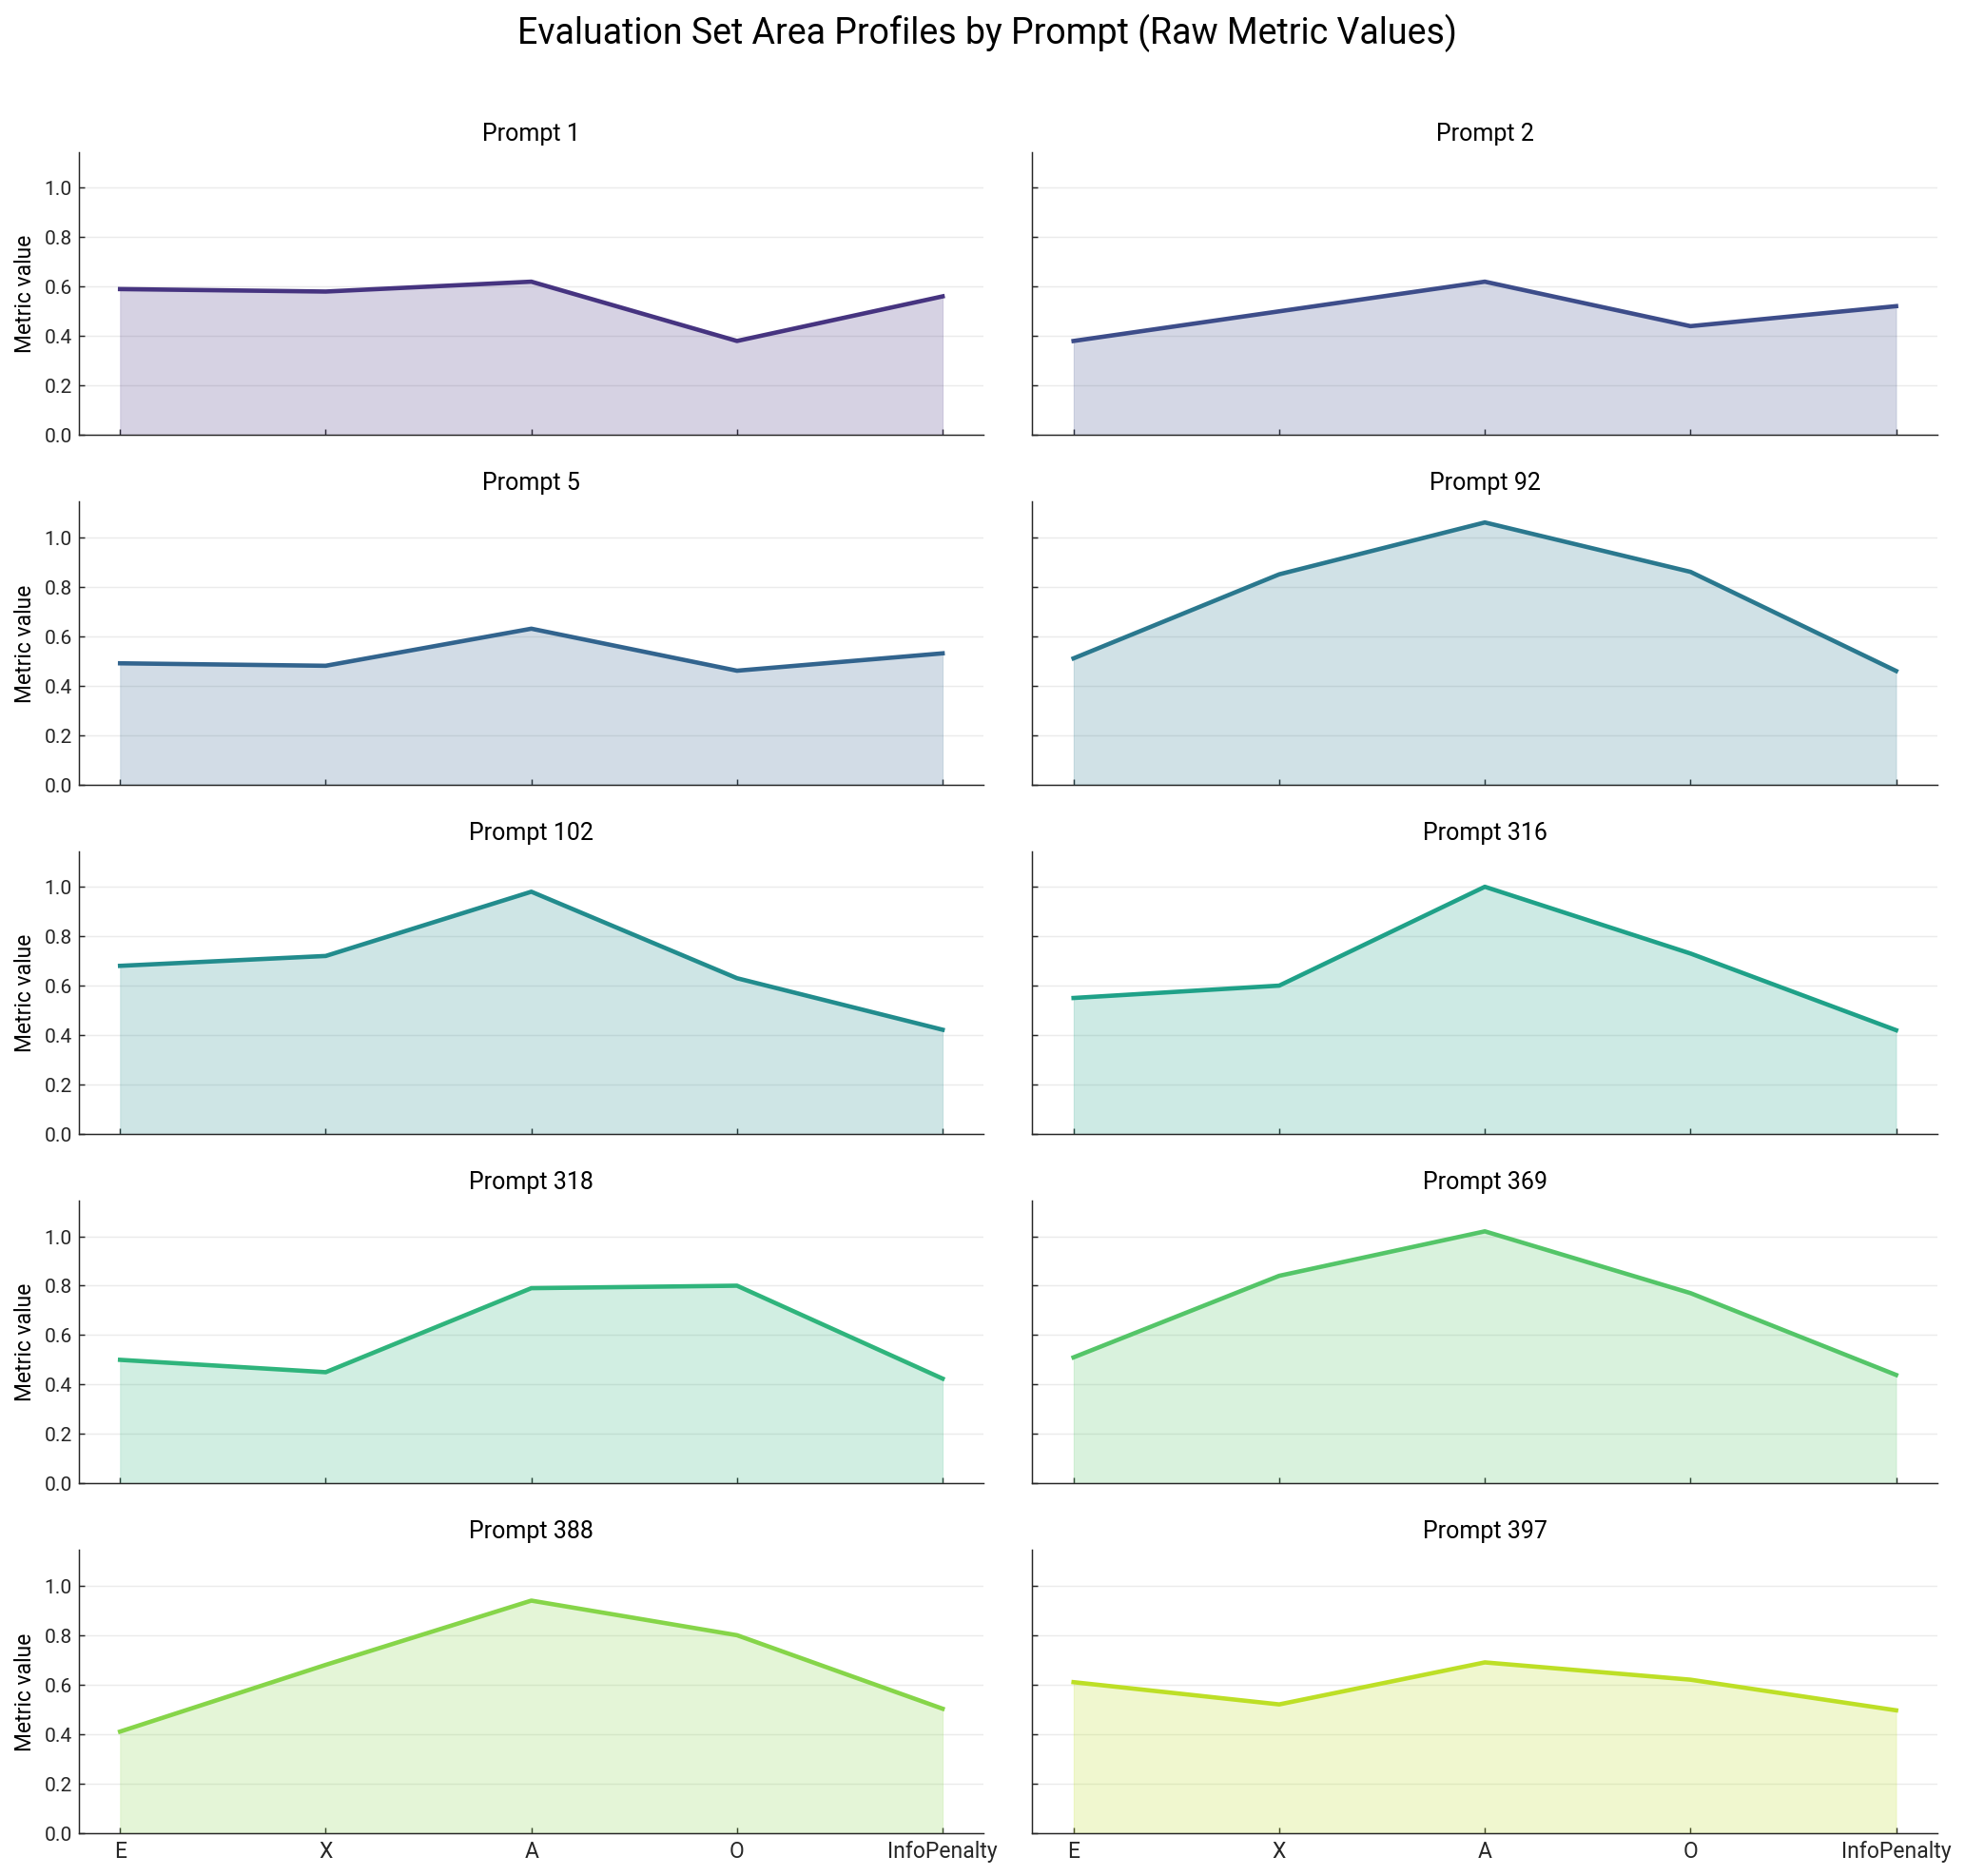

,prompt_id,e_abs_dev,x_abs_dev,a_abs_dev,o_abs_dev,information_penalty
0,1,0.59,0.58,0.62,0.38,0.560486
1,2,0.38,0.50,0.62,0.44,0.520871
2,5,0.49,0.48,0.63,0.46,0.530322
3,92,0.51,0.85,1.06,0.86,0.459044
4,102,0.68,0.72,0.98,0.63,0.421481
5,316,0.55,0.60,1.00,0.73,0.419712
6,318,0.50,0.45,0.79,0.80,0.423992
7,369,0.51,0.84,1.02,0.77,0.438935
8,388,0.41,0.68,0.94,0.80,0.502491
9,397,0.61,0.52,0.69,0.62,0.496067


In [15]:
from pathlib import Path

eval_reward = pd.read_csv("../results/metaprompt_tuning/eval_reward.csv")
eval_steps_path = Path("../results/metaprompt_tuning/eval_steps.csv")
if eval_steps_path.exists():
    eval_steps = pd.read_csv(eval_steps_path)
else:
    eval_steps = pd.read_csv("../results/metaprompt_tuning/eval_results.csv")

if "prompt_lookup" not in globals():
    raise ValueError(
        "prompt_lookup is required to map evaluation prompts to prompt IDs."
    )

eval_reward = eval_reward.copy()
eval_reward["meta_prompt"] = eval_reward["meta_prompt"].astype(str).str.strip()
eval_reward = eval_reward.merge(
    prompt_lookup[["meta_prompt", "prompt_id"]],
    on="meta_prompt",
    how="left",
    validate="many_to_one",
)
if eval_reward["prompt_id"].isna().any():
    raise ValueError("Some eval_reward prompts could not be mapped to prompt_id.")
eval_reward["prompt_id"] = eval_reward["prompt_id"].astype(int)

for axis in ["e", "x", "a", "o"]:
    eval_reward[f"{axis}_abs_dev"] = (
        pd.to_numeric(eval_reward[f"{axis}_recon"], errors="coerce")
        - pd.to_numeric(eval_reward[f"{axis}_trait"], errors="coerce")
    ).abs()

if "prompt_id" in eval_steps.columns:
    final_prompt_ids = (
        pd.to_numeric(eval_steps["prompt_id"], errors="coerce")
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )
elif "meta_prompt" in eval_steps.columns:
    final_prompt_ids = (
        eval_steps["meta_prompt"]
        .astype(str)
        .str.strip()
        .map(prompt_lookup.set_index("meta_prompt")["prompt_id"])
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )
elif "prompt" in eval_steps.columns:
    final_prompt_ids = (
        eval_steps["prompt"]
        .astype(str)
        .str.strip()
        .map(prompt_lookup.set_index("meta_prompt")["prompt_id"])
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )
else:
    raise ValueError(
        "eval_steps/eval_results must contain one of: prompt_id, meta_prompt, or prompt."
    )

radar_metrics = (
    eval_reward.loc[eval_reward["prompt_id"].isin(final_prompt_ids)]
    .groupby("prompt_id", as_index=False)
    .agg(
        e_abs_dev=("e_abs_dev", "mean"),
        x_abs_dev=("x_abs_dev", "mean"),
        a_abs_dev=("a_abs_dev", "mean"),
        o_abs_dev=("o_abs_dev", "mean"),
        information_penalty=("information_penalty", "mean"),
    )
    .sort_values("prompt_id")
    .reset_index(drop=True)
)

dimensions = [
    "e_abs_dev",
    "x_abs_dev",
    "a_abs_dev",
    "o_abs_dev",
    "information_penalty",
]
dimension_labels = ["E", "X", "A", "O", "InfoPenalty"]

area_plot = radar_metrics.copy()

n_prompts = len(area_plot)
n_cols = 2
n_rows = int(np.ceil(n_prompts / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 2.6 * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.array(axes).reshape(-1)

x = np.arange(len(dimensions))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, n_prompts))
y_max = float(area_plot[dimensions].max().max())

for ax, color, row in zip(axes, colors, area_plot.itertuples(index=False)):
    values = np.array([getattr(row, col) for col in dimensions])
    ax.plot(x, values, color=color, linewidth=2.2)
    ax.fill_between(x, values, 0, color=color, alpha=0.22)
    ax.set_title(f"Prompt {int(row.prompt_id)}", fontsize=12, pad=6)
    ax.set_ylim(0, y_max * 1.08)
    ax.grid(axis="y", alpha=0.25, linewidth=0.7)

for idx in range(n_prompts, len(axes)):
    axes[idx].axis("off")

for idx, ax in enumerate(axes[:n_prompts]):
    ax.set_xticks(x)
    if idx >= (n_rows - 1) * n_cols:
        ax.set_xticklabels(dimension_labels, fontsize=11)
    else:
        ax.set_xticklabels([])
    if idx % n_cols == 0:
        ax.set_ylabel("Metric value", fontsize=11)

fig.suptitle(
    "Evaluation Set Area Profiles by Prompt (Raw Metric Values)",
    fontsize=18,
    y=1.01,
)
fig.tight_layout()
plt.show()

radar_metrics

### Prompt 2 Interaction Analysis
Analyze how changing one trait parameter influences reconstruction on all personality axes for a single prompt.

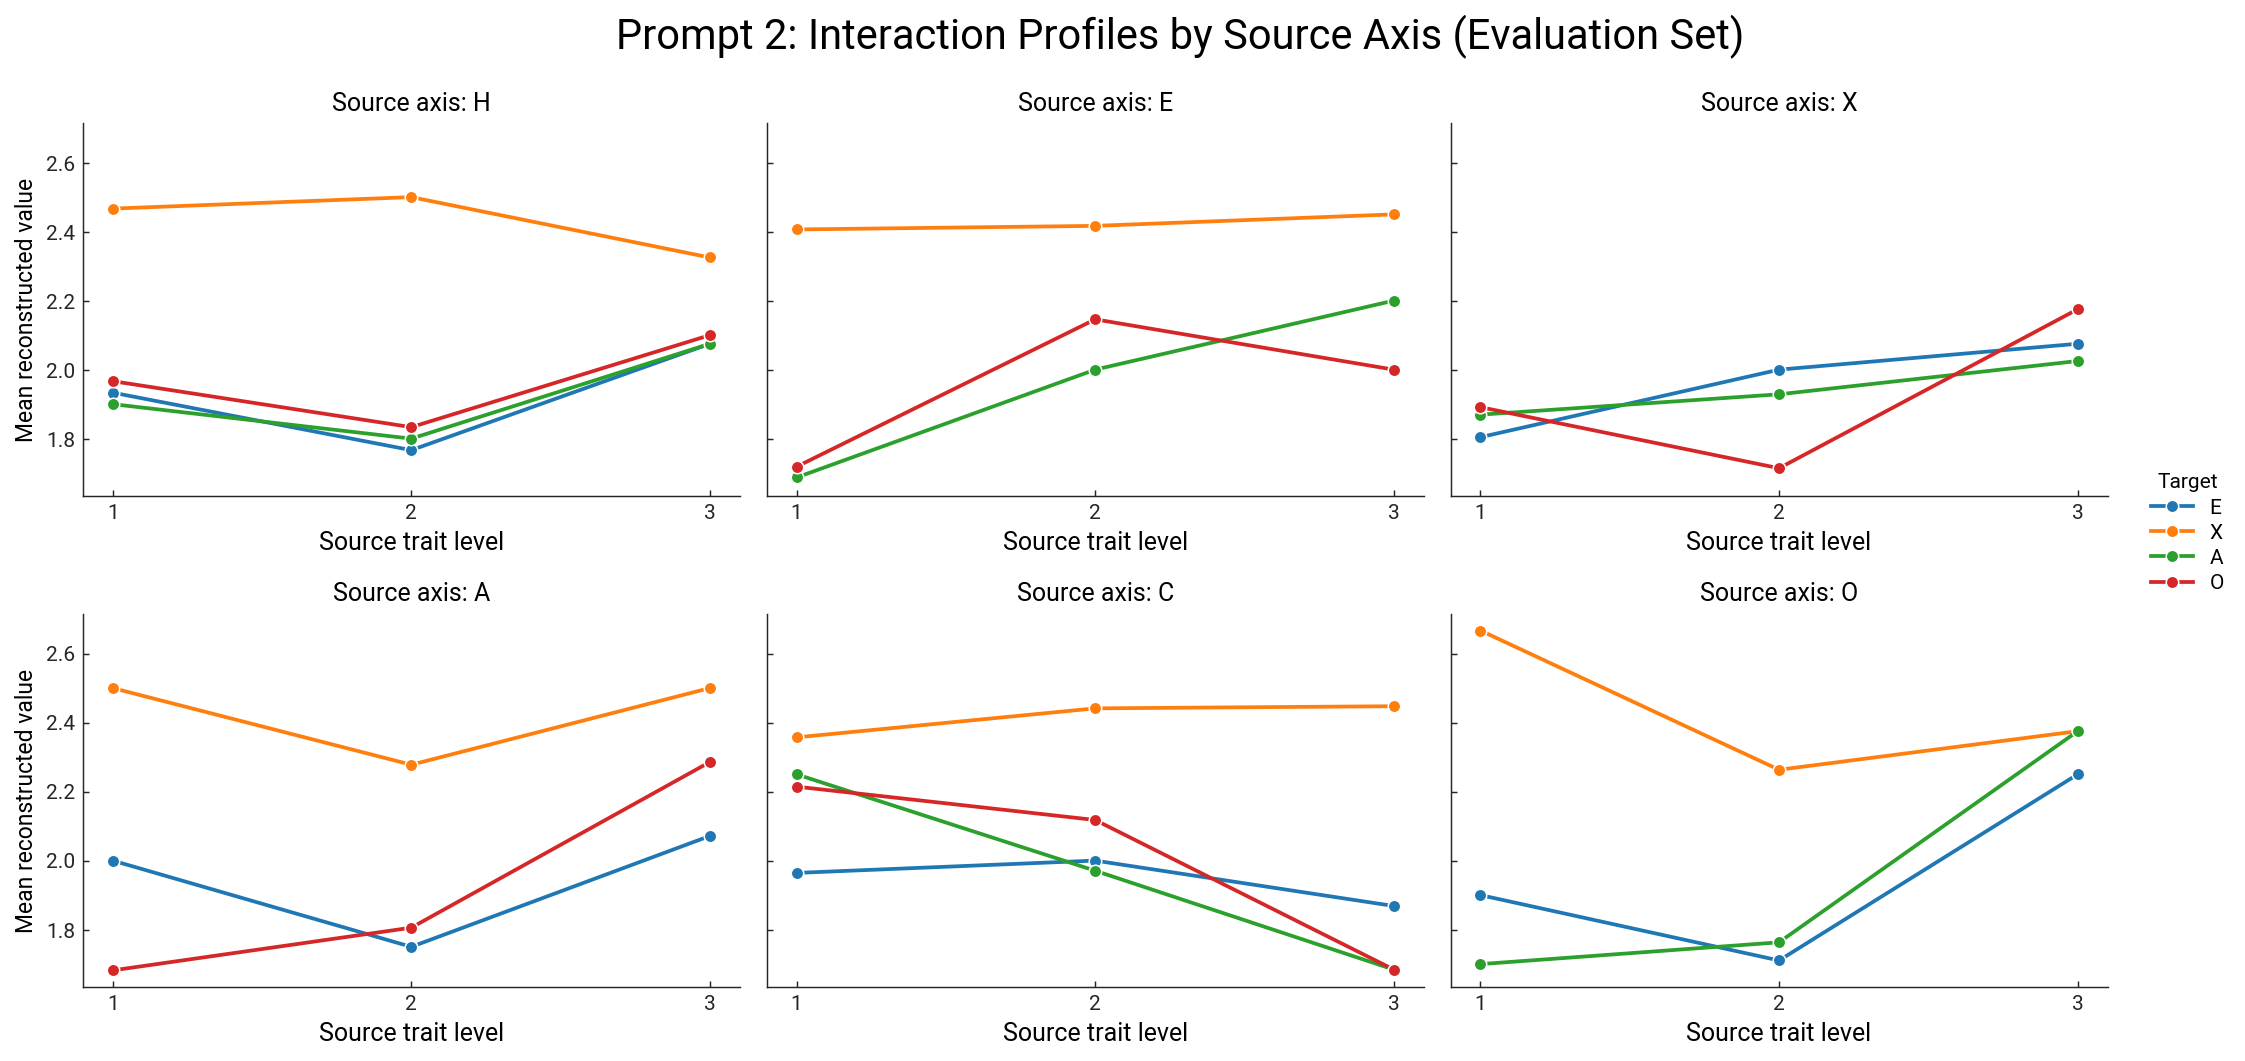

In [16]:
prompt_focus_id = 2
if "prompt_lookup" not in globals():
    raise ValueError(
        "prompt_lookup is required to map evaluation prompts to prompt IDs."
    )

eval_reward = pd.read_csv("../results/metaprompt_tuning/eval_reward.csv")
eval_reward["meta_prompt"] = eval_reward["meta_prompt"].astype(str).str.strip()
eval_reward = eval_reward.merge(
    prompt_lookup[["meta_prompt", "prompt_id"]],
    on="meta_prompt",
    how="left",
    validate="many_to_one",
)
if eval_reward["prompt_id"].isna().any():
    raise ValueError("Some eval_reward prompts could not be mapped to prompt_id.")
eval_reward["prompt_id"] = eval_reward["prompt_id"].astype(int)

focus_df = eval_reward.loc[eval_reward["prompt_id"] == prompt_focus_id].copy()
if focus_df.empty:
    raise ValueError(f"No evaluation rows found for prompt_id={prompt_focus_id}.")

all_axis_codes = ["h", "e", "x", "a", "c", "o"]
source_axes = [axis for axis in all_axis_codes if f"{axis}_trait" in focus_df.columns]
target_axes = [axis for axis in all_axis_codes if f"{axis}_recon" in focus_df.columns]

if len(source_axes) == 0 or len(target_axes) == 0:
    raise ValueError(
        "No compatible trait/reconstruction axis columns found for interaction analysis."
    )

source_labels = [axis.upper() for axis in source_axes]

plot_rows = []
for source in source_axes:
    trait_col = f"{source}_trait"
    trait_values = pd.to_numeric(focus_df[trait_col], errors="coerce")
    for target in target_axes:
        if source == target:
            continue
        recon_col = f"{target}_recon"
        recon_values = pd.to_numeric(focus_df[recon_col], errors="coerce")
        tmp = pd.DataFrame(
            {
                "source_axis": source.upper(),
                "target_axis": target.upper(),
                "trait_level": trait_values,
                "recon_value": recon_values,
            }
        ).dropna()
        if tmp.empty:
            continue
        grouped = (
            tmp.groupby(["source_axis", "target_axis", "trait_level"], as_index=False)
            .agg(mean_recon=("recon_value", "mean"), n=("recon_value", "size"))
            .sort_values("trait_level")
        )
        plot_rows.append(grouped)

if len(plot_rows) == 0:
    raise ValueError(
        f"No non-null cross-axis interaction data available for prompt_id={prompt_focus_id}."
    )

interaction_plot_df = pd.concat(plot_rows, ignore_index=True)
present_target_labels = [
    axis
    for axis in [a.upper() for a in target_axes]
    if axis in interaction_plot_df["target_axis"].unique()
]

n_sources = len(source_labels)
n_cols = 3
n_rows = int(np.ceil(n_sources / n_cols))
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(5.3 * n_cols, 3.6 * n_rows), sharey=True
)
axes = np.array(axes).reshape(-1)
legend_handles = None
legend_labels = None

for i, source_axis in enumerate(source_labels):
    ax = axes[i]
    src_df = interaction_plot_df.loc[interaction_plot_df["source_axis"] == source_axis]
    sns.lineplot(
        data=src_df,
        x="trait_level",
        y="mean_recon",
        hue="target_axis",
        hue_order=present_target_labels,
        marker="o",
        linewidth=1.8,
        legend=(i == 0),
        ax=ax,
    )
    ax.set_title(f"Source axis: {source_axis}")
    ax.set_xlabel("Source trait level")
    ax.set_ylabel("Mean reconstructed value", fontsize=11)
    ax.set_xticks(sorted(src_df["trait_level"].unique()))
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        legend_handles = handles
        legend_labels = labels
        if ax.get_legend() is not None:
            ax.get_legend().remove()

for j in range(n_sources, len(axes)):
    axes[j].axis("off")

if legend_handles is not None and legend_labels is not None:
    fig.legend(
        legend_handles,
        legend_labels,
        title="Target",
        loc="center left",
        bbox_to_anchor=(0.9, 0.5),
        frameon=False,
    )

fig.suptitle(
    f"Prompt {prompt_focus_id}: Interaction Profiles by Source Axis (Evaluation Set)",
    fontsize=20,
)
fig.tight_layout(rect=(0, 0, 0.9, 1))
plt.show()